# EDA - Veterinarios de Alemania

## Preparación del entorno

### 1. Setup - Importar librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

# Configuración de gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 150

### 2. Configuración

In [4]:
data_input = "../data/raw/1.Germany/germany.veterinarians.csv"
data_output = "../data/processed/germany.veterinarians.csv"
report_output = "../data/reports/"
model_output = "../data/models/"

target = "Burnout_Score"
target_dependiente = ["Burnout_Score", "CBI_SCORE"]

columnas_categoricas = ["status of employment", "field of work", "federal state", "community size", "gender", "income"]

columnas_ERI = ["ERI_1","ERI_2","ERI_3","ERI_4","ERI_5","ERI_6","ERI_7","ERI_8","ERI_9","ERI_10"]
columnas_CBI = ["CBI_01","CBI_02","CBI_03","CBI_04","CBI_05","CBI_06"]
columnas_OTHERS = ["REDONDEAR","gender","status of employment","field of work","federal state","community size","income"]

### 3. Mapeo de valores

In [5]:
valores_cbi = {
    1: 100,
    2: 75,
    3: 50,
    4: 25,
    5: 0
}

### 4. Cargar los datos

In [6]:
# Cargar datos
print("-" * 50)
print(f"Cargando datos de: {data_input}")
print("-" * 50)

df = pd.read_csv(data_input)
print("Datos iniciales...")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
print("-" * 50)
print("\nPrimeras 5 filas:")
display(df.head())

--------------------------------------------------
Cargando datos de: ../data/raw/1.Germany/germany.veterinarians.csv
--------------------------------------------------
Datos iniciales...
Filas: 3179, Columnas: 27
--------------------------------------------------

Primeras 5 filas:


,ERI_1,ERI_2,ERI_3,ERI_4,ERI_5,ERI_6,ERI_7,ERI_8,ERI_9,ERI_10,...,birth year,status of employment,field of work,federal state,community size,income,working hours,TRANSLATE,CONVERT,REDONDEAR
0,3,3,3,1,3,3,3,2,2,1,...,1986.0,9,12,2,2,1,60,60,60,60
1,2,2,2,3,3,2,1,3,3,3,...,1980.0,2,9,4,2,3,35,35,35,35
2,3,3,3,3,2,2,1,3,3,3,...,1989.0,2,9,4,1,3,42,42,42,42
3,3,4,4,1,2,2,2,2,2,3,...,1984.0,2,5,4,3,3,45,45,45,45
4,3,3,3,3,2,2,2,3,3,3,...,1978.0,2,2,4,4,2,40,40,40,40


### 5. Limpieza y transformación de datos

- Convertimos las columnas numéricas a tipo Int64
- Tratamos los valores inválidos como np.nan
- Eliminamos las columnas "working hours", "TRANSLATE", "CONVERT"
- Renombramos la columna "REDONDEAR" a "working_hours"

In [7]:
# Limpieza y transformación de datos
print("-" * 50)
print("Limpiando y transformando columnas...")
print("-" * 50)

# Convertir columnas a Int64 (tipo entero nulo)
df[columnas_ERI] = df[columnas_ERI].apply(pd.to_numeric, errors='coerce').astype('Int64')
df[columnas_CBI] = df[columnas_CBI].apply(pd.to_numeric, errors='coerce').astype('Int64')
df[columnas_OTHERS] = df[columnas_OTHERS].apply(pd.to_numeric, errors='coerce').astype('Int64')

# Validar que los valores estén en el rango esperado
df[columnas_ERI] = df[columnas_ERI].where(df[columnas_ERI].isin([1, 2, 3, 4]), np.nan)
df[columnas_CBI] = df[columnas_CBI].where(df[columnas_CBI].isin([1, 2, 3, 4, 5]), np.nan)

# Validar columnas categóricas
df["status of employment"] = df["status of employment"].where(
    df["status of employment"].isin([1, 2, 3, 4, 5, 6, 7, 8, 9]), np.nan
)
df["field of work"] = df["field of work"].where(
    df["field of work"].isin([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]), np.nan
)
df["federal state"] = df["federal state"].where(
    df["federal state"].isin([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]), np.nan
)
df["community size"] = df["community size"].where(
    df["community size"].isin([1, 2, 3, 4]), np.nan
)
df["gender"] = df["gender"].where(df["gender"].isin([1, 2]), np.nan)
df["income"] = df["income"].where(df["income"].isin([1, 2, 3, 4, 5, 6]), np.nan)

# Rellenar birth year con NaN
df['birth year'] = df['birth year'].fillna(np.nan)

# Eliminar columnas intermedias
cols_to_drop = ["working hours", "TRANSLATE", "CONVERT"]
df = df.drop(cols_to_drop, axis=1)

# Renombrar REDONDEAR a working_hours
df = df.rename(columns={"REDONDEAR": "working_hours"})
df["working_hours"] = df["working_hours"].apply(
    pd.to_numeric, errors='coerce'
).astype('Int64')

print(f"Columnas después de la limpieza: {len(df.columns)}")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

--------------------------------------------------
Limpiando y transformando columnas...
--------------------------------------------------
Columnas después de la limpieza: 24
Filas: 3179, Columnas: 24


In [8]:
# Verificar valores faltantes
print("-" * 50)
print("Valores faltantes en el dataset:")
print("-" * 50)

print("Cuenta de valores faltantes por columna:")
missing_counts = df.isna().sum().sort_values(ascending=False)
display(missing_counts)

--------------------------------------------------
Valores faltantes en el dataset:
--------------------------------------------------
Cuenta de valores faltantes por columna:


birth year              14
community size          13
income                  12
ERI_1                    1
ERI_5                    1
ERI_2                    1
ERI_3                    1
ERI_4                    1
ERI_8                    1
ERI_7                    1
ERI_6                    1
ERI_9                    1
CBI_03                   1
ERI_10                   1
CBI_01                   1
CBI_02                   1
CBI_06                   1
CBI_05                   1
CBI_04                   1
gender                   1
field of work            1
status of employment     1
federal state            1
working_hours            0
dtype: int64

### 6. Eliminar valores faltantes

In [9]:
# Eliminar valores faltantes
print("-" * 50)
print("Creando dataset limpio (eliminando filas con valores faltantes)...")
print("-" * 50)

df_clean = df.copy()
df_clean = df_clean.dropna()

# Registrar pérdida de datos
print(f"Filas originales: {len(df)}")
print(f"Filas limpias: {len(df_clean)}")
print(f"Filas eliminadas: {len(df) - len(df_clean)}")
print(f"Filas: {df_clean.shape[0]}, Columnas: {df_clean.shape[1]}")

del df  # Liberar memoria del dataframe original

--------------------------------------------------
Creando dataset limpio (eliminando filas con valores faltantes)...
--------------------------------------------------
Filas originales: 3179
Filas limpias: 3148
Filas eliminadas: 31
Filas: 3148, Columnas: 24


**Información del dataset procesado**

In [10]:
print("-" * 50)
print("Información del dataset limpio:")
print("-" * 50)
df_clean.info()

--------------------------------------------------
Información del dataset limpio:
--------------------------------------------------
<class 'pandas.DataFrame'>
Index: 3148 entries, 0 to 3178
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ERI_1                 3148 non-null   Int64  
 1   ERI_2                 3148 non-null   Int64  
 2   ERI_3                 3148 non-null   Int64  
 3   ERI_4                 3148 non-null   Int64  
 4   ERI_5                 3148 non-null   Int64  
 5   ERI_6                 3148 non-null   Int64  
 6   ERI_7                 3148 non-null   Int64  
 7   ERI_8                 3148 non-null   Int64  
 8   ERI_9                 3148 non-null   Int64  
 9   ERI_10                3148 non-null   Int64  
 10  CBI_01                3148 non-null   Int64  
 11  CBI_02                3148 non-null   Int64  
 12  CBI_03                3148 non-null   Int64  
 13  CBI_0

Calcular la edad de los individuos

In [11]:
# Calcular edad
print("-" * 50)
print("Calculando edad a partir del año de nacimiento...")
print("-" * 50)

if 'birth year' in df_clean.columns:
    df_clean['birth year'] = pd.to_numeric(df_clean['birth year'], errors='coerce').replace(0, np.nan)
    df_clean['age'] = pd.Timestamp.today().year - df_clean['birth year']

print("Estadísticas de edad:")

if 'age' in df_clean.columns:
    display(df_clean[['birth year', 'age']].describe())
else:
    print("No se creó la columna de edad")

--------------------------------------------------
Calculando edad a partir del año de nacimiento...
--------------------------------------------------
Estadísticas de edad:


,birth year,age
count,3148.000000,3148.000000
mean,1974.763977,51.236023
std,11.197928,11.197928
min,1926.000000,26.000000
25%,1966.000000,42.000000
50%,1977.000000,49.000000
75%,1984.000000,60.000000
max,2000.000000,100.000000


Filtramos registros que no se usaron para el TFM.

In [12]:
print("-" * 50)
print("Filtrando rango de edad y horas laborales...")
print("-" * 50)

# Filtrar rango de edad y laboral definido para el TFM
df_clean = df_clean[df_clean["age"].between(22, 75)]
df_clean = df_clean[df_clean["working_hours"].between(0, 80)]

print(f"Filas después del filtrado: {df_clean.shape[0]}, Columnas: {df_clean.shape[1]}")

--------------------------------------------------
Filtrando rango de edad y horas laborales...
--------------------------------------------------
Filas después del filtrado: 3053, Columnas: 25


### 7. Variable objetivo

Nuestra variable objetivo es "Burnout_Score", que identificará a aquellos individuos dentro del percentil 80 del promedio de las columnas CBI: "CBI_01", "CBI_02", "CBI_03", "CBI_04", "CBI_05", "CBI_06".

Reemplazamos los valores de las columnas CBI por su valor equivalente para calcular el CBI SCORE.
Puntajes (1=100, 2=75, 3=50, 4=25, 5=0)

In [13]:
print("-" * 50)
print("Reemplazando valores de CBI por su equivalencia en porcentaje...")
print("-" * 50)

df_clean[columnas_CBI] = df_clean[columnas_CBI].replace(valores_cbi)

df_clean[columnas_CBI] = df_clean[columnas_CBI].apply(
    pd.to_numeric, errors='coerce'
).astype('Int64')

--------------------------------------------------
Reemplazando valores de CBI por su equivalencia en porcentaje...
--------------------------------------------------


**Nota**: La variable objetivo Burnout_Score se construyó a partir del indicador CBI_SCORE. Después de calcular el promedio de las puntuaciones obtenidas en los ítems CBI_01 a CBI_06, se utilizó un punto de corte de 50 puntos. Los individuos con puntuaciones iguales o superiores a 50 fueron clasificados como casos de burnout (valor = 1), mientras que aquellos con puntuaciones inferiores fueron clasificados como no burnout (valor = 0). Este criterio se basa en la interpretación propuesta para el Copenhagen Burnout Inventory, donde puntuaciones iguales o superiores a 50 indican la presencia de síntomas clínicamente relevantes de burnout. Embrace Autism - Copenhagen Burnout Inventory

In [14]:
# Crear variable objetivo
print("-" * 50)
print("Creando variable objetivo Burnout_Score...")
print("-" * 50)

# Calculamos el promedio de la sumatoria de CBI
df_clean["CBI_SCORE"] = df_clean[columnas_CBI].mean(axis=1).round(1)

# Función para crear variable objetivo binaria
def crear_target_burnout(df, percentil=50):
    df = df.copy()
    df["Burnout_Score"] = (df["CBI_SCORE"] >= percentil).astype(int)
    return df

df_clean = crear_target_burnout(df_clean)

print("Variable objetivo creada. Distribución de Burnout_Score:")
print(df_clean["Burnout_Score"].value_counts())

--------------------------------------------------
Creando variable objetivo Burnout_Score...
--------------------------------------------------
Variable objetivo creada. Distribución de Burnout_Score:
Burnout_Score
1    1630
0    1423
Name: count, dtype: int64


In [15]:
df_eda = df_clean.copy()
del df_clean  # Liberar memoria del dataframe limpio

Guardar copia del dataset para el dashboard

In [16]:
print("-" * 50)
print(f"Guardando dataset procesado en: {data_output}")
print("-" * 50)
df_eda.to_csv(data_output, index=False)

--------------------------------------------------
Guardando dataset procesado en: ../data/processed/germany.veterinarians.csv
--------------------------------------------------


Realizamos un reporte de las estadisticas de nuestras variables.

In [17]:
# Estadísticas descriptivas
summary = df_eda.describe(include='all').transpose()
summary.to_csv(os.path.join(report_output, 'EDA_Reporte.csv'))
print("-" * 50)
print("Estadísticas descriptivas:")
print("-" * 50)
display(summary)

--------------------------------------------------
Estadísticas descriptivas:
--------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
ERI_1,3053.0,2.94661,0.725924,1.0,3.0,3.0,3.0,4.0
ERI_2,3053.0,2.85719,0.752396,1.0,2.0,3.0,3.0,4.0
ERI_3,3053.0,2.820504,0.769171,1.0,2.0,3.0,3.0,4.0
ERI_4,3053.0,2.49394,0.841101,1.0,2.0,3.0,3.0,4.0
ERI_5,3053.0,2.75696,0.860077,1.0,2.0,3.0,3.0,4.0
ERI_6,3053.0,2.215198,0.804561,1.0,2.0,2.0,3.0,4.0
ERI_7,3053.0,1.801179,0.812403,1.0,1.0,2.0,2.0,4.0
ERI_8,3053.0,2.353095,0.799607,1.0,2.0,2.0,3.0,4.0
ERI_9,3053.0,2.424828,0.761973,1.0,2.0,2.0,3.0,4.0
ERI_10,3053.0,2.124468,0.873128,1.0,1.0,2.0,3.0,4.0


In [18]:
# Conteos categóricos
print("-" * 50)
print("Conteos categóricos:")
print("-" * 50)
# Guardar conteos en archivo
with open(os.path.join(report_output, 'EDA_conteo_de_categorias.txt')  , 'w', encoding='utf-8') as f:
    for col in (columnas_categoricas):
        if col in df_eda.columns:
            f.write(f'\n=== {col} ===\n')
            f.write(df_eda[col].value_counts(dropna=False).sort_index().to_string())
            f.write('\n')

# Mostrar conteos
for col in (columnas_categoricas):
    if col in df_eda.columns:
        display(df_eda[col].value_counts(dropna=False).sort_index().to_frame('count'))

--------------------------------------------------
Conteos categóricos:
--------------------------------------------------


,count
status of employment,
1,828
2,1990
3,25
4,56
5,36
6,7
7,6
8,10
9,95


,count
field of work,
1,2417
2,375
3,124
4,12
5,4
6,8
7,3
8,5
9,43


,count
federal state,
1,320
2,691
3,126
4,139
5,6
6,54
7,196
8,38
9,417


,count
community size,
1,967
2,629
3,485
4,972


,count
gender,
1,620
2,2433


,count
income,
1,443
2,956
3,782
4,417
5,241
6,214


## Análisis Exploratorio de Datos (EDA)

### Análisis Univariante

--------------------------------------------------
Generando histogramas de características numéricas...
--------------------------------------------------


<Figure size 2700x2100 with 0 Axes>

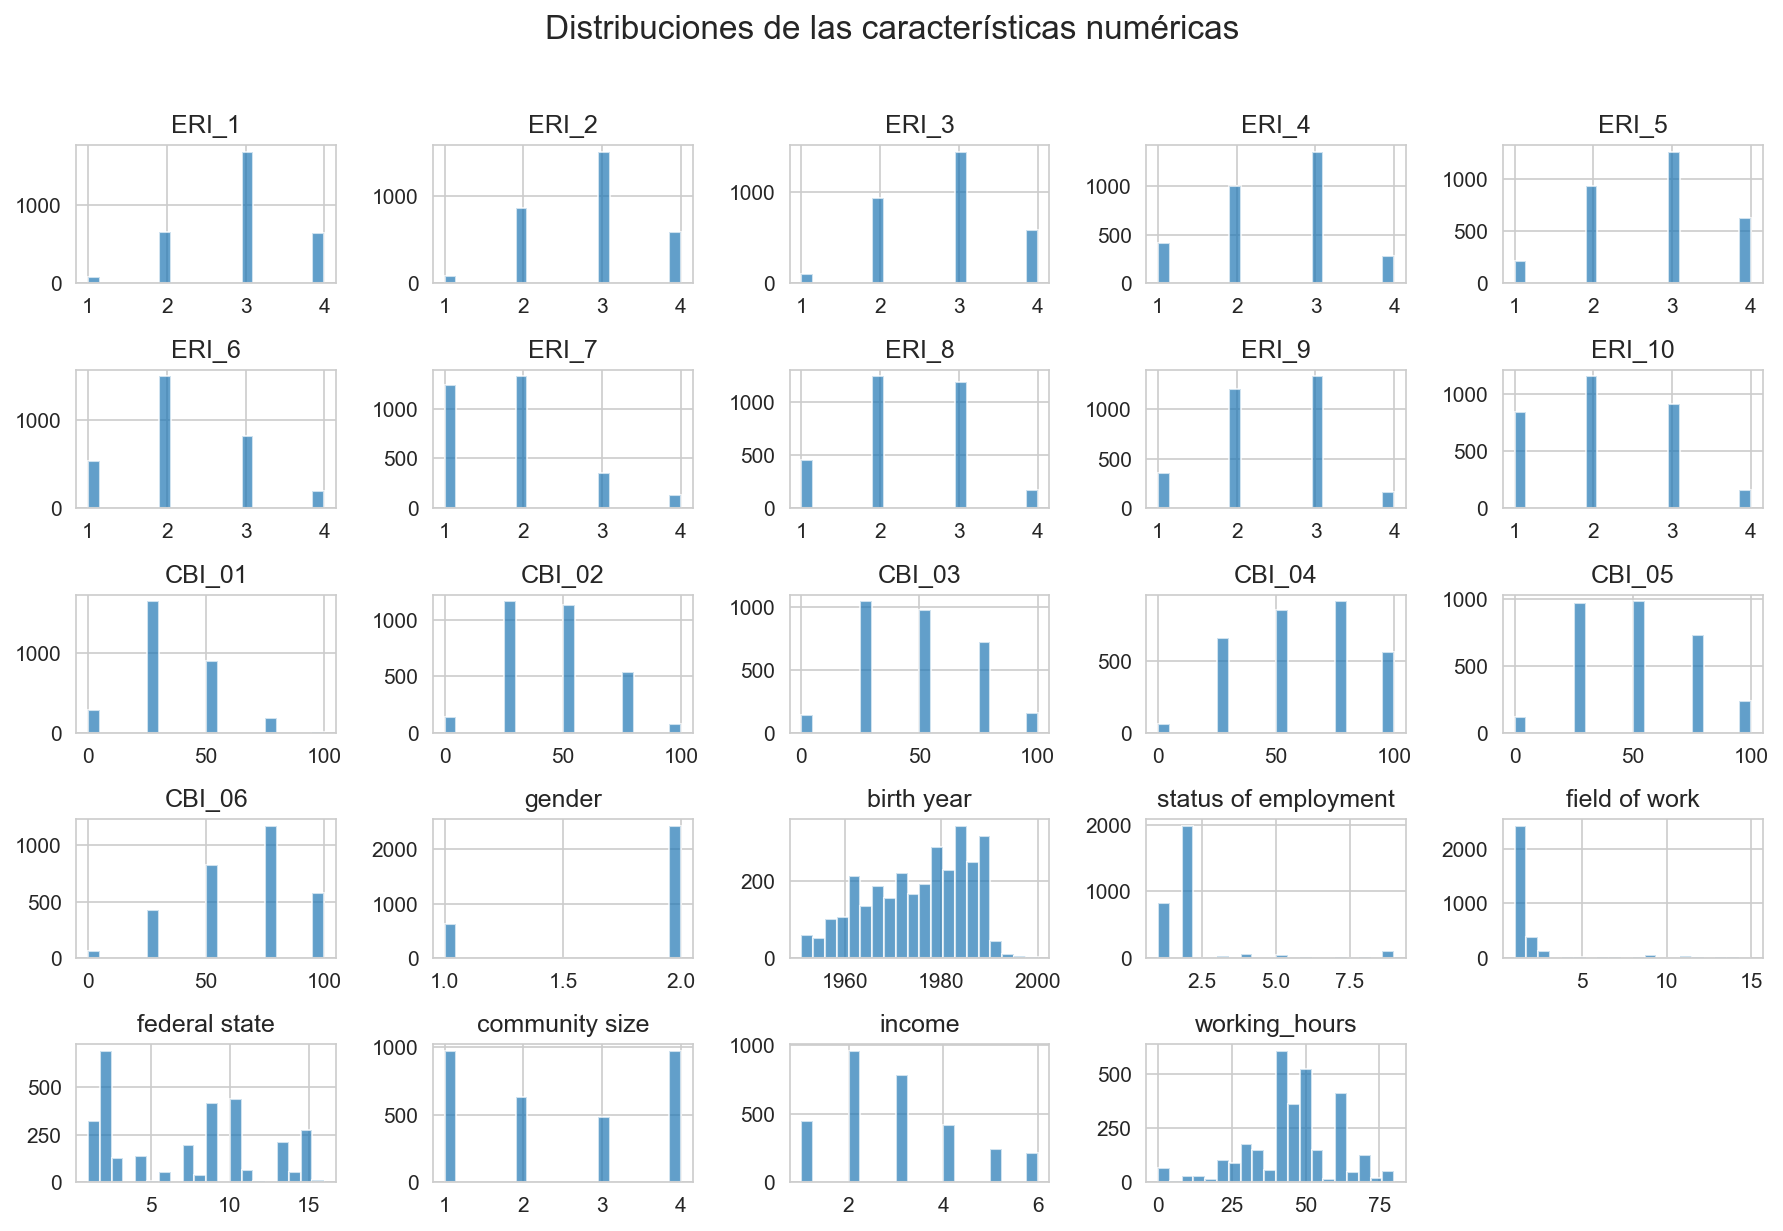

--------------------------------------------------
Reportes y gráficos guardados en la carpeta de reports: ../data/reports/EDA_distribuciones_numericas.png
--------------------------------------------------


In [19]:
# Histogramas con etiquetas
print("-" * 50)
print("Generando histogramas de características numéricas...")
print("-" * 50)
plt.figure(figsize=(18, 14))
numeric_cols = df_eda.select_dtypes(include='number').columns.tolist()
plot_cols = [c for c in numeric_cols if c != target][:24]
df_eda[plot_cols].hist(bins=20, alpha=0.7)
plt.suptitle('Distribuciones de las características numéricas', y=1.02, fontsize=16)
plt.xlabel('Característica')
plt.ylabel('Conteo')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(report_output, 'EDA_distribuciones_numericas.png'), dpi=150)
plt.show()
print("-" * 50)
print(f"Reportes y gráficos guardados en la carpeta de reports: {report_output}EDA_distribuciones_numericas.png")
print("-" * 50)

--------------------------------------------------
Burnout_Score
0    1423
1    1630
Name: count, dtype: int64
--------------------------------------------------
Porcentaje de clase positiva (burnout): 53.39%
--------------------------------------------------


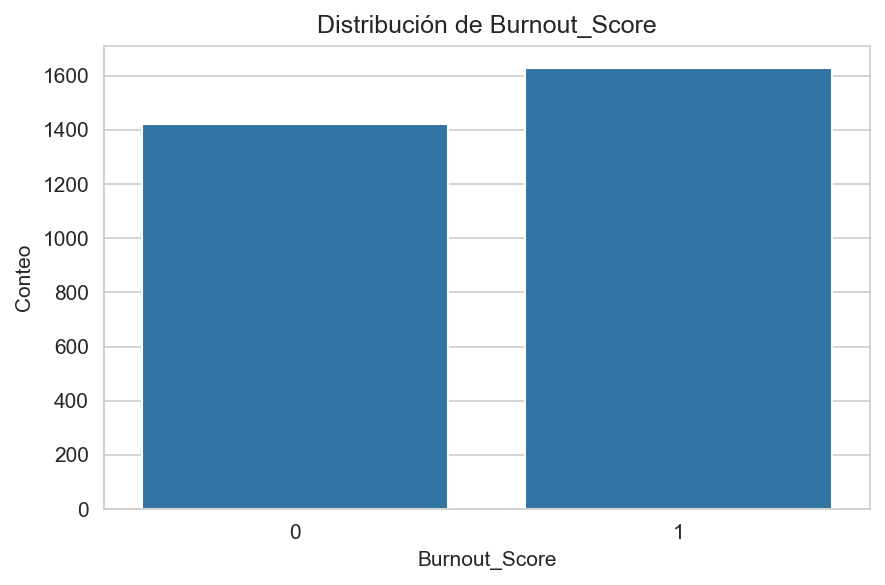

--------------------------------------------------
Gráfico de distribución de la variable objetivo guardado en: ../data/reports/EDA_distribucion_objetivo.png
--------------------------------------------------


In [20]:
# Verificar variable objetivo
assert target in df_eda.columns, f'Falta columna objetivo: {target}'
assert set(df_eda[target].dropna().unique()).issubset({0, 1}), 'El objetivo no es binario 0/1.'

target_counts = df_eda[target].value_counts(dropna=False).sort_index()
print("-" * 50)
print(target_counts)
print("-" * 50)
print(f'Porcentaje de clase positiva (burnout): {df_eda[target].mean():.2%}')
print("-" * 50)

# Graficar distribución
plt.figure(figsize=(6, 4))
sns.countplot(data=df_eda, x=target)
plt.title('Distribución de Burnout_Score')
plt.xlabel('Burnout_Score')
plt.ylabel('Conteo')
plt.tight_layout()
plt.savefig(os.path.join(report_output, 'EDA_distribucion_objetivo.png'), dpi=150)
plt.show()
print("-" * 50)
print(f"Gráfico de distribución de la variable objetivo guardado en: {report_output}EDA_distribucion_objetivo.png")
print("-" * 50)

### Análisis Bivariante:

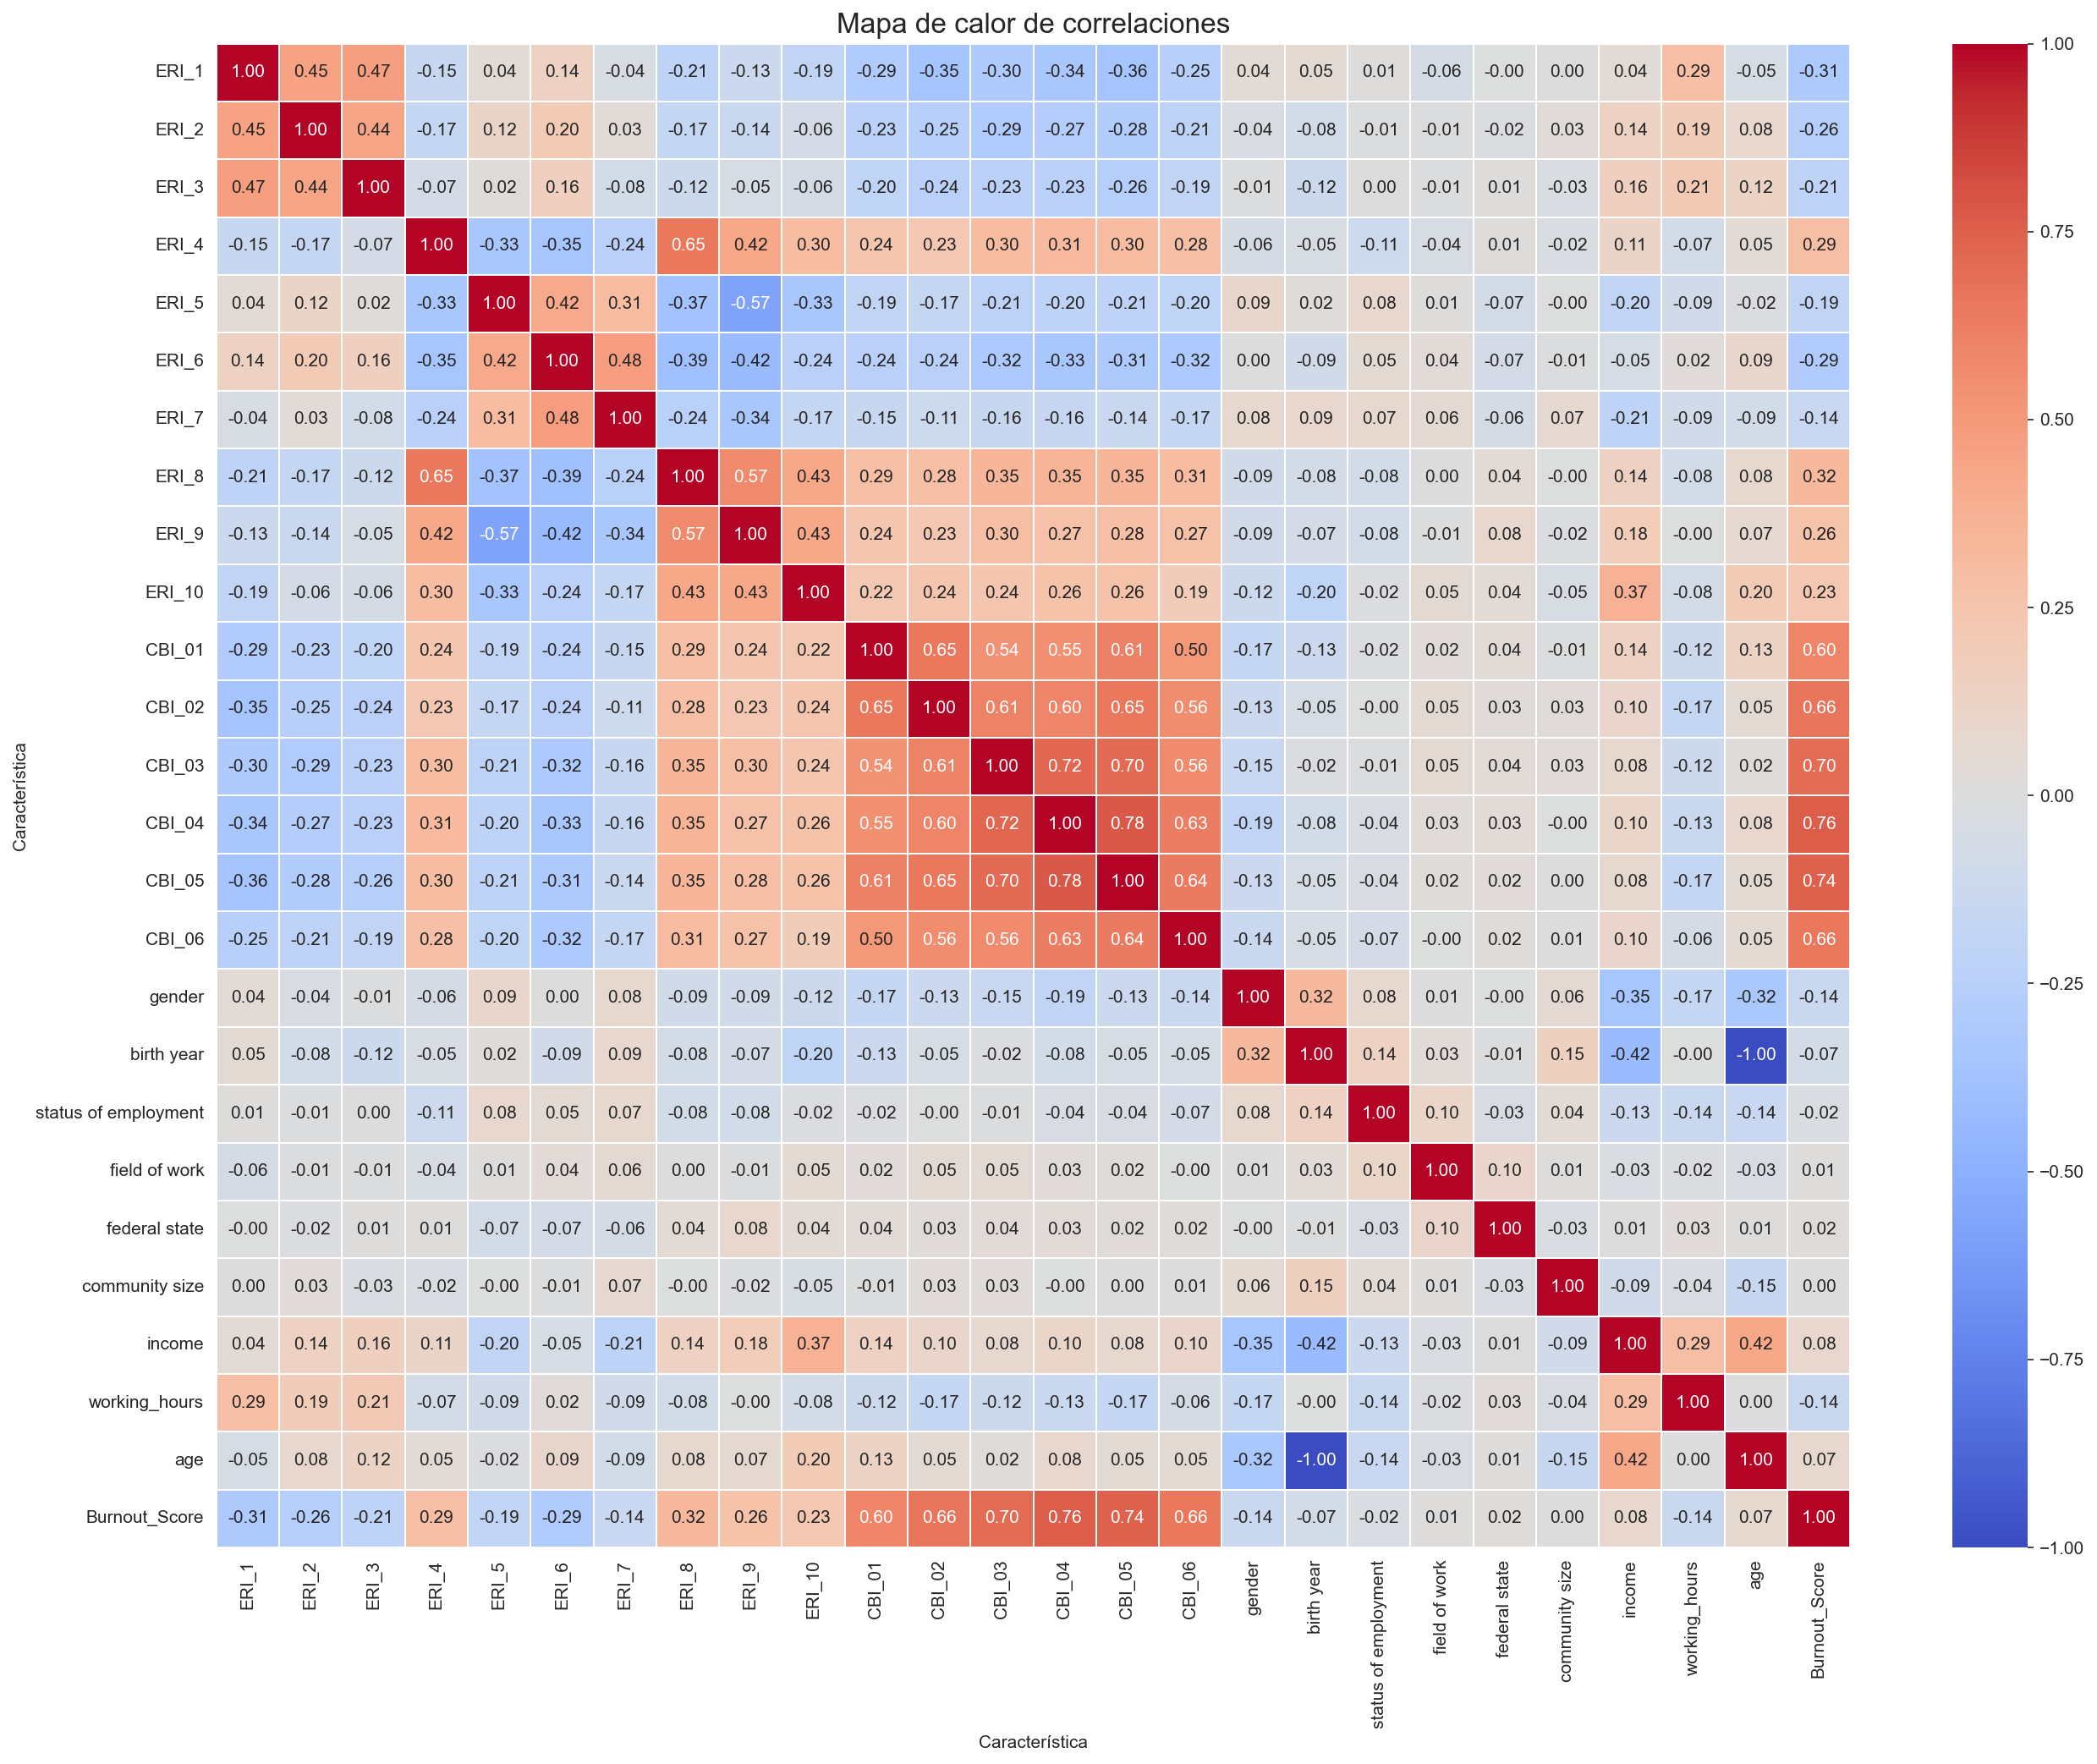

--------------------------------------------------
Mapa de calor de correlaciones guardado en: ../data/reports/EDA_mapa_de_calor_de_correlaciones.png
--------------------------------------------------
--------------------------------------------------
Correlaciones con el objetivo:
--------------------------------------------------

Top 15 correlaciones positivas con Burnout_Score:


Burnout_Score    1.000000
CBI_04           0.757829
CBI_05           0.744837
CBI_03           0.697798
CBI_02           0.658615
CBI_06           0.655661
CBI_01           0.595207
ERI_8            0.323963
ERI_1            0.306655
ERI_6            0.293660
ERI_4            0.289572
ERI_9            0.263324
ERI_2            0.261167
ERI_10           0.232499
ERI_3            0.208686
Name: Burnout_Score, dtype: float64


Top 15 correlaciones negativas con Burnout_Score (factores protectores):


ERI_9                   0.263324
ERI_2                   0.261167
ERI_10                  0.232499
ERI_3                   0.208686
ERI_5                   0.194587
ERI_7                   0.143825
gender                  0.140336
working_hours           0.140299
income                  0.082727
age                     0.074835
birth year              0.074835
status of employment    0.023455
federal state           0.020190
field of work           0.013324
community size          0.002363
Name: Burnout_Score, dtype: float64

In [21]:
# Mapa de calor de correlación con etiquetas
df_eda = df_eda.drop(columns=["CBI_SCORE"])
corr = df_eda.select_dtypes(include='number').corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.2, annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.title('Mapa de calor de correlaciones', fontsize=16)
plt.xlabel('Característica')
plt.ylabel('Característica')
plt.tight_layout()
plt.savefig(os.path.join(report_output, 'EDA_mapa_de_calor_de_correlaciones.png'), dpi=150)
plt.show()
print("-" * 50)
print(f"Mapa de calor de correlaciones guardado en: {report_output}EDA_mapa_de_calor_de_correlaciones.png")
print("-" * 50)

# Correlaciones con el objetivo
print("-" * 50)
print("Correlaciones con el objetivo:")
print("-" * 50)

print("\nTop 15 correlaciones positivas con Burnout_Score:")
display(corr[target].abs().sort_values(ascending=False).head(15))

print("\nTop 15 correlaciones negativas con Burnout_Score (factores protectores):")
display(corr[target].abs().sort_values(ascending=False).tail(15))

In [22]:
# Análisis bivariante de características numéricas con la variable objetivo "Burnout_Score"

numerical_features = [ "age", "income", "working_hours" ]

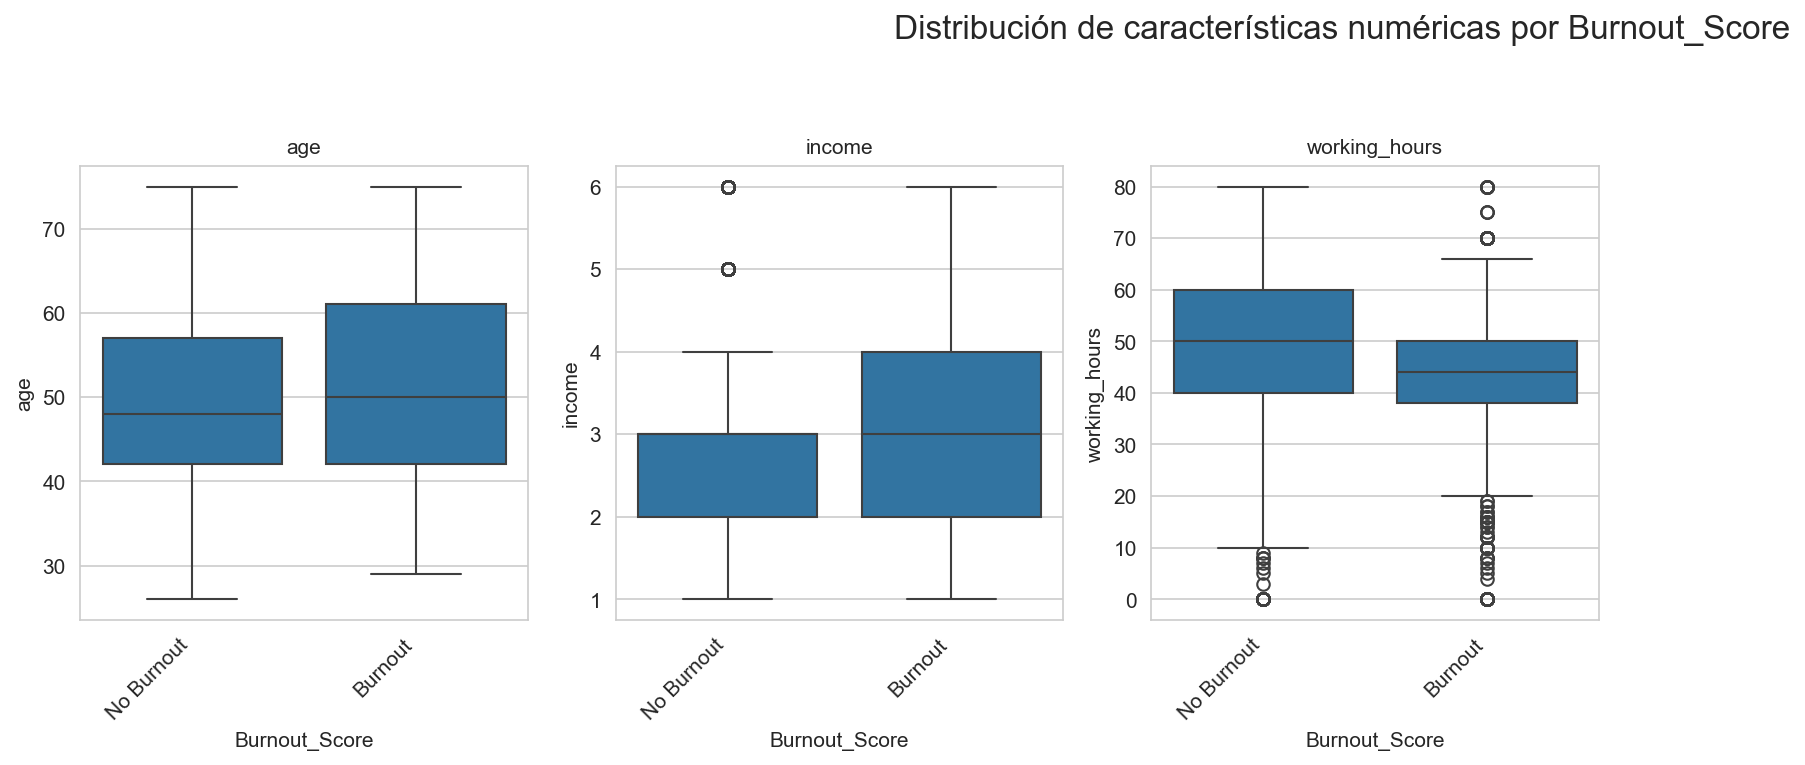

In [23]:
fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.boxplot(x=target, y=col, data=df_eda, ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("Burnout_Score")
    axes[i].set_ylabel(col)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["No Burnout", "Burnout"], rotation=45, ha='right')

# Hide unused axes (19 features, 20 subplots)
for j in range(len(numerical_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de características numéricas por Burnout_Score', y=1.02, fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(report_output, 'EDA_boxplots_numericos.png'), dpi=150)
plt.show()

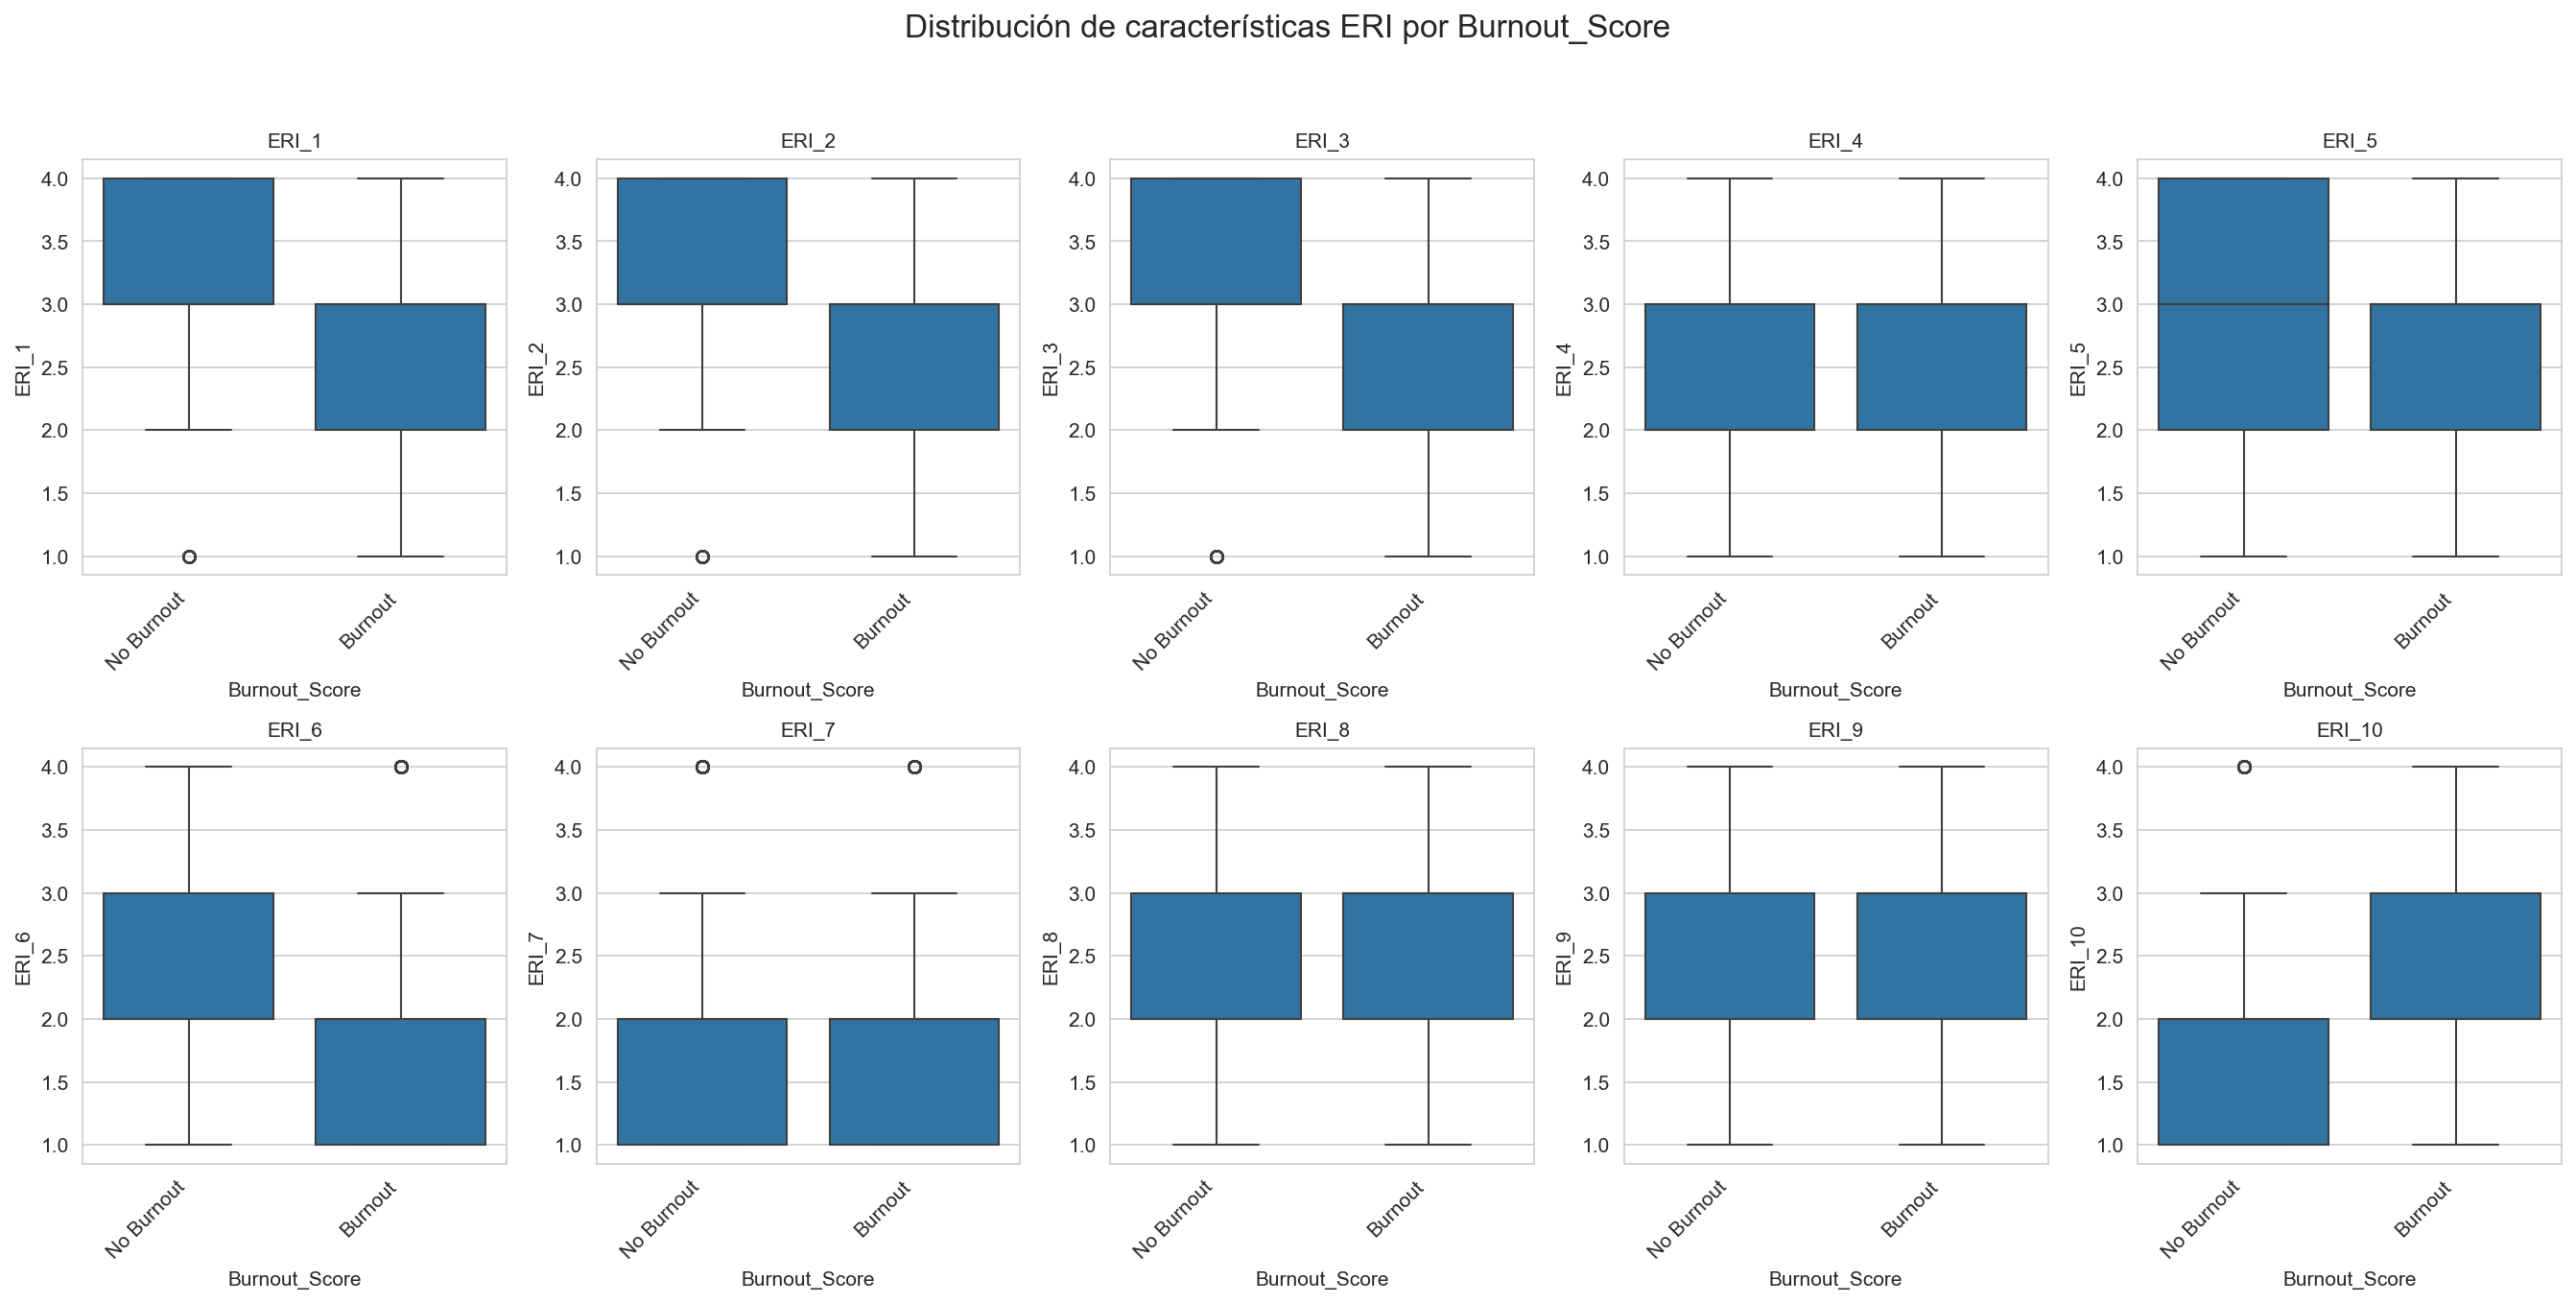

In [24]:
fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(columnas_ERI):
    sns.boxplot(x=target, y=col, data=df_eda, ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("Burnout_Score")
    axes[i].set_ylabel(col)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["No Burnout", "Burnout"], rotation=45, ha='right')

# Hide unused axes (19 features, 20 subplots)
for j in range(len(columnas_ERI), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de características ERI por Burnout_Score', y=1.02, fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(report_output, 'EDA_boxplots_ERI.png'), dpi=150)
plt.show()

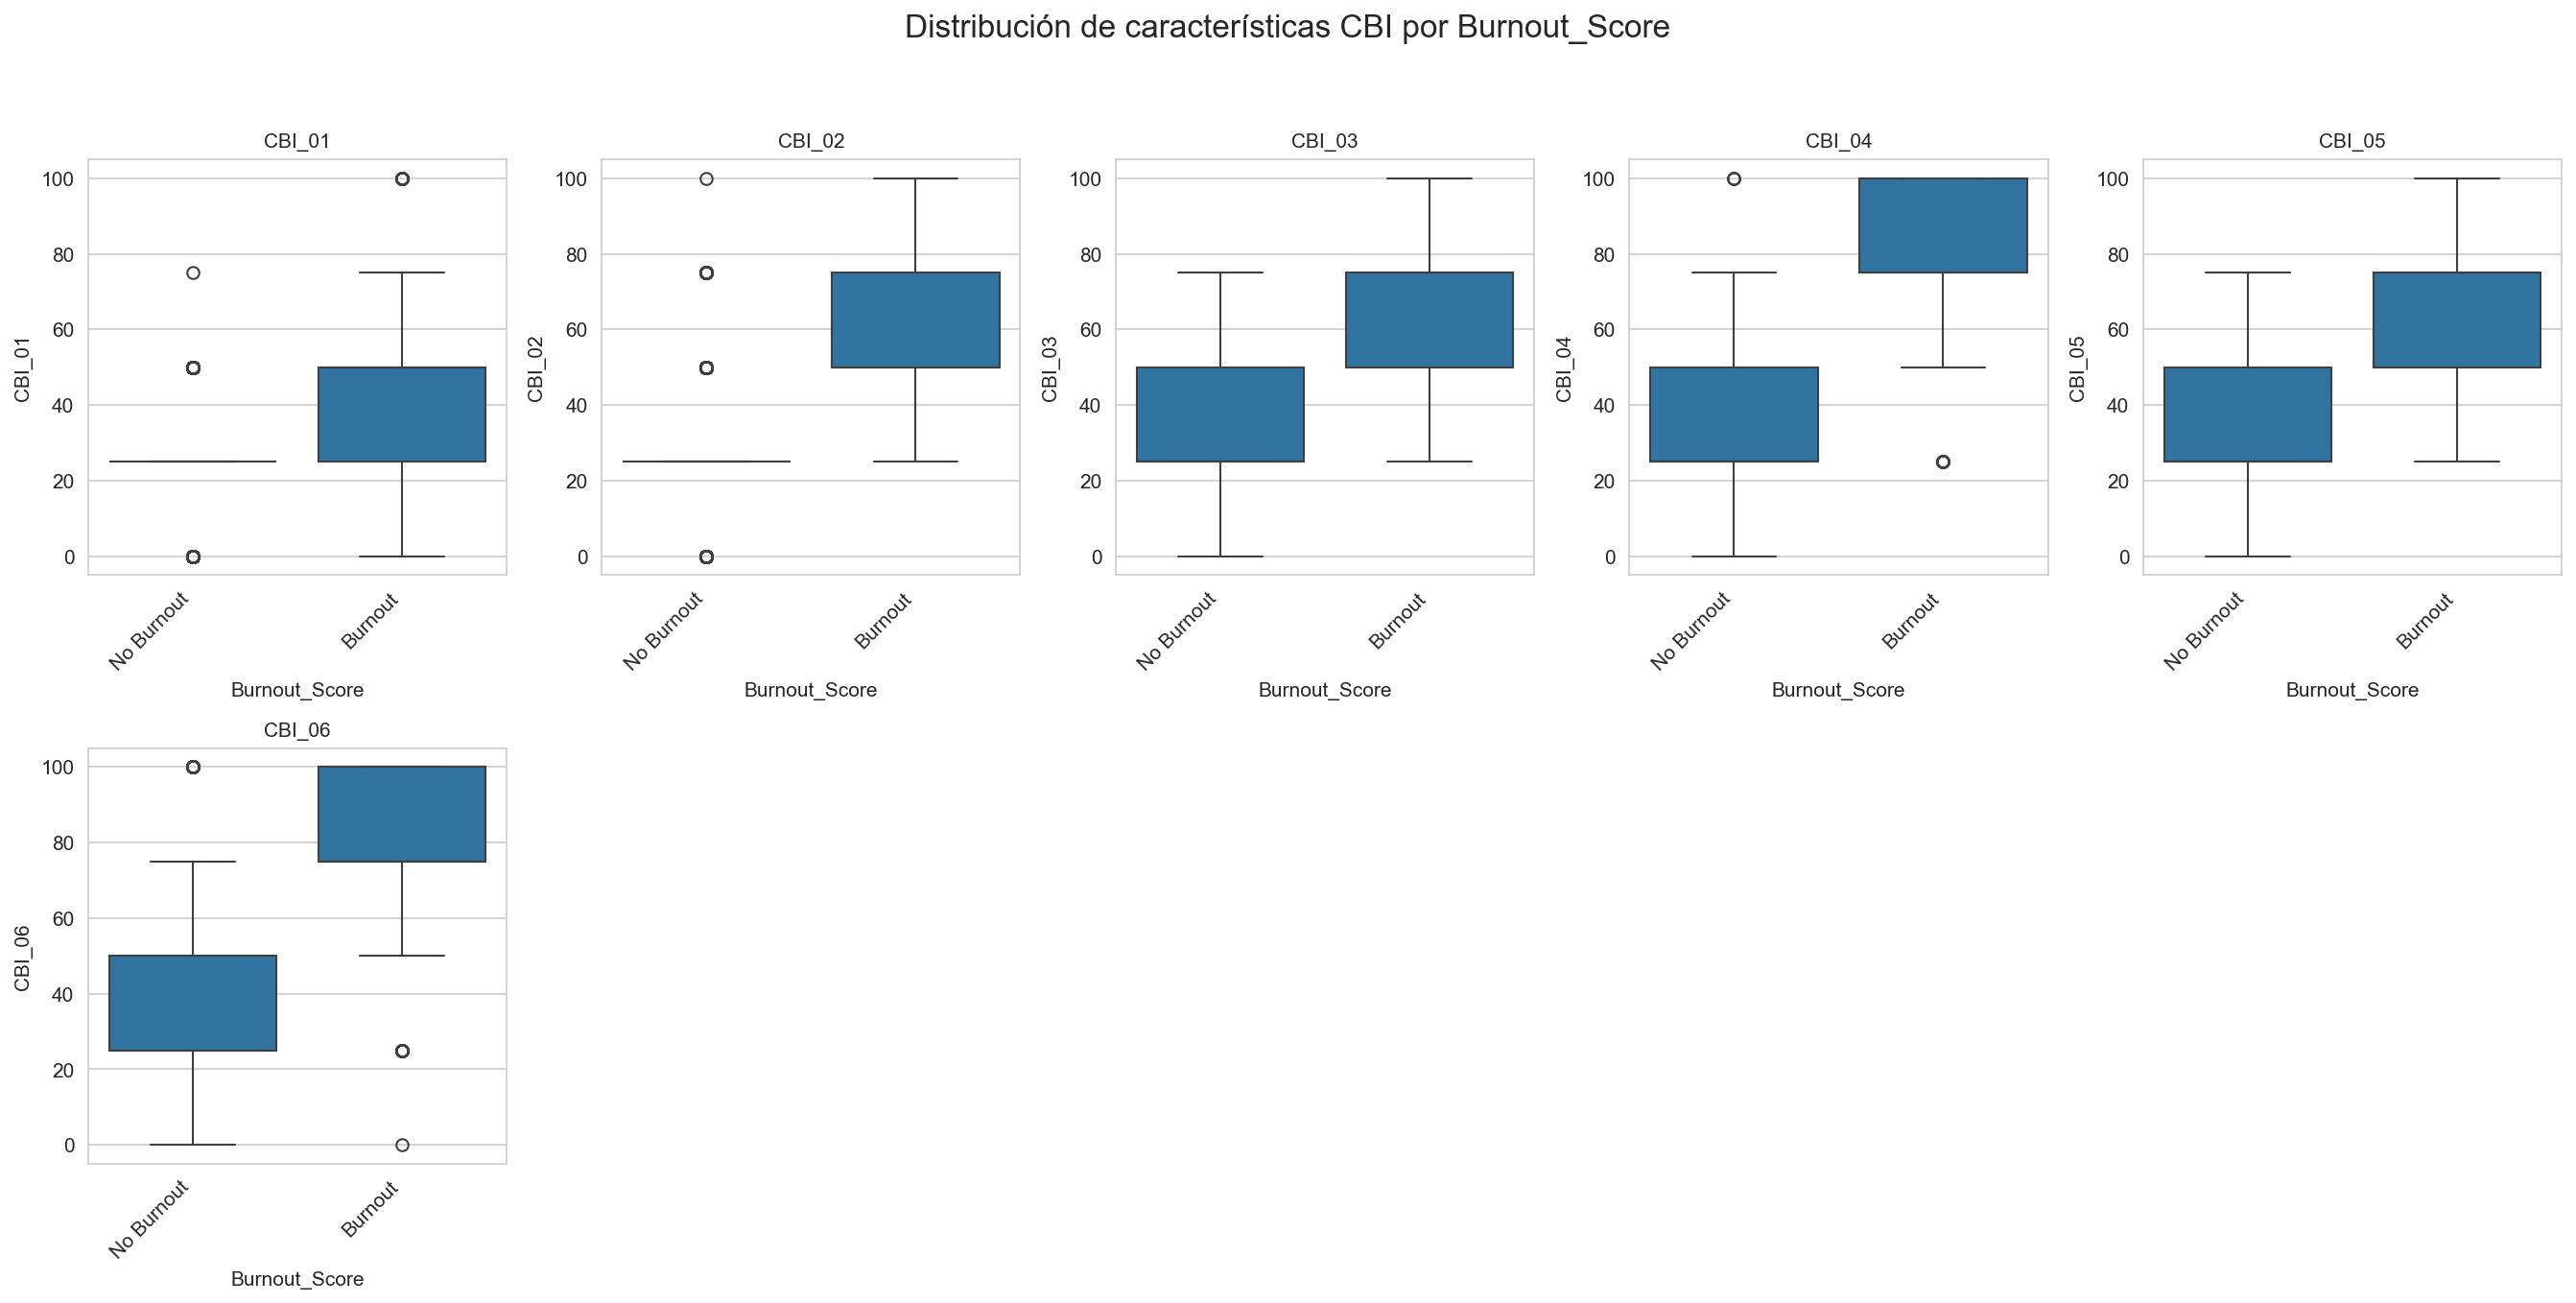

In [25]:
fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(columnas_CBI):
    sns.boxplot(x=target, y=col, data=df_eda, ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("Burnout_Score")
    axes[i].set_ylabel(col)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["No Burnout", "Burnout"], rotation=45, ha='right')

# Hide unused axes (19 features, 20 subplots)
for j in range(len(columnas_CBI), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de características CBI por Burnout_Score', y=1.02, fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(report_output, 'EDA_boxplots_CBI.png'), dpi=150)
plt.show()

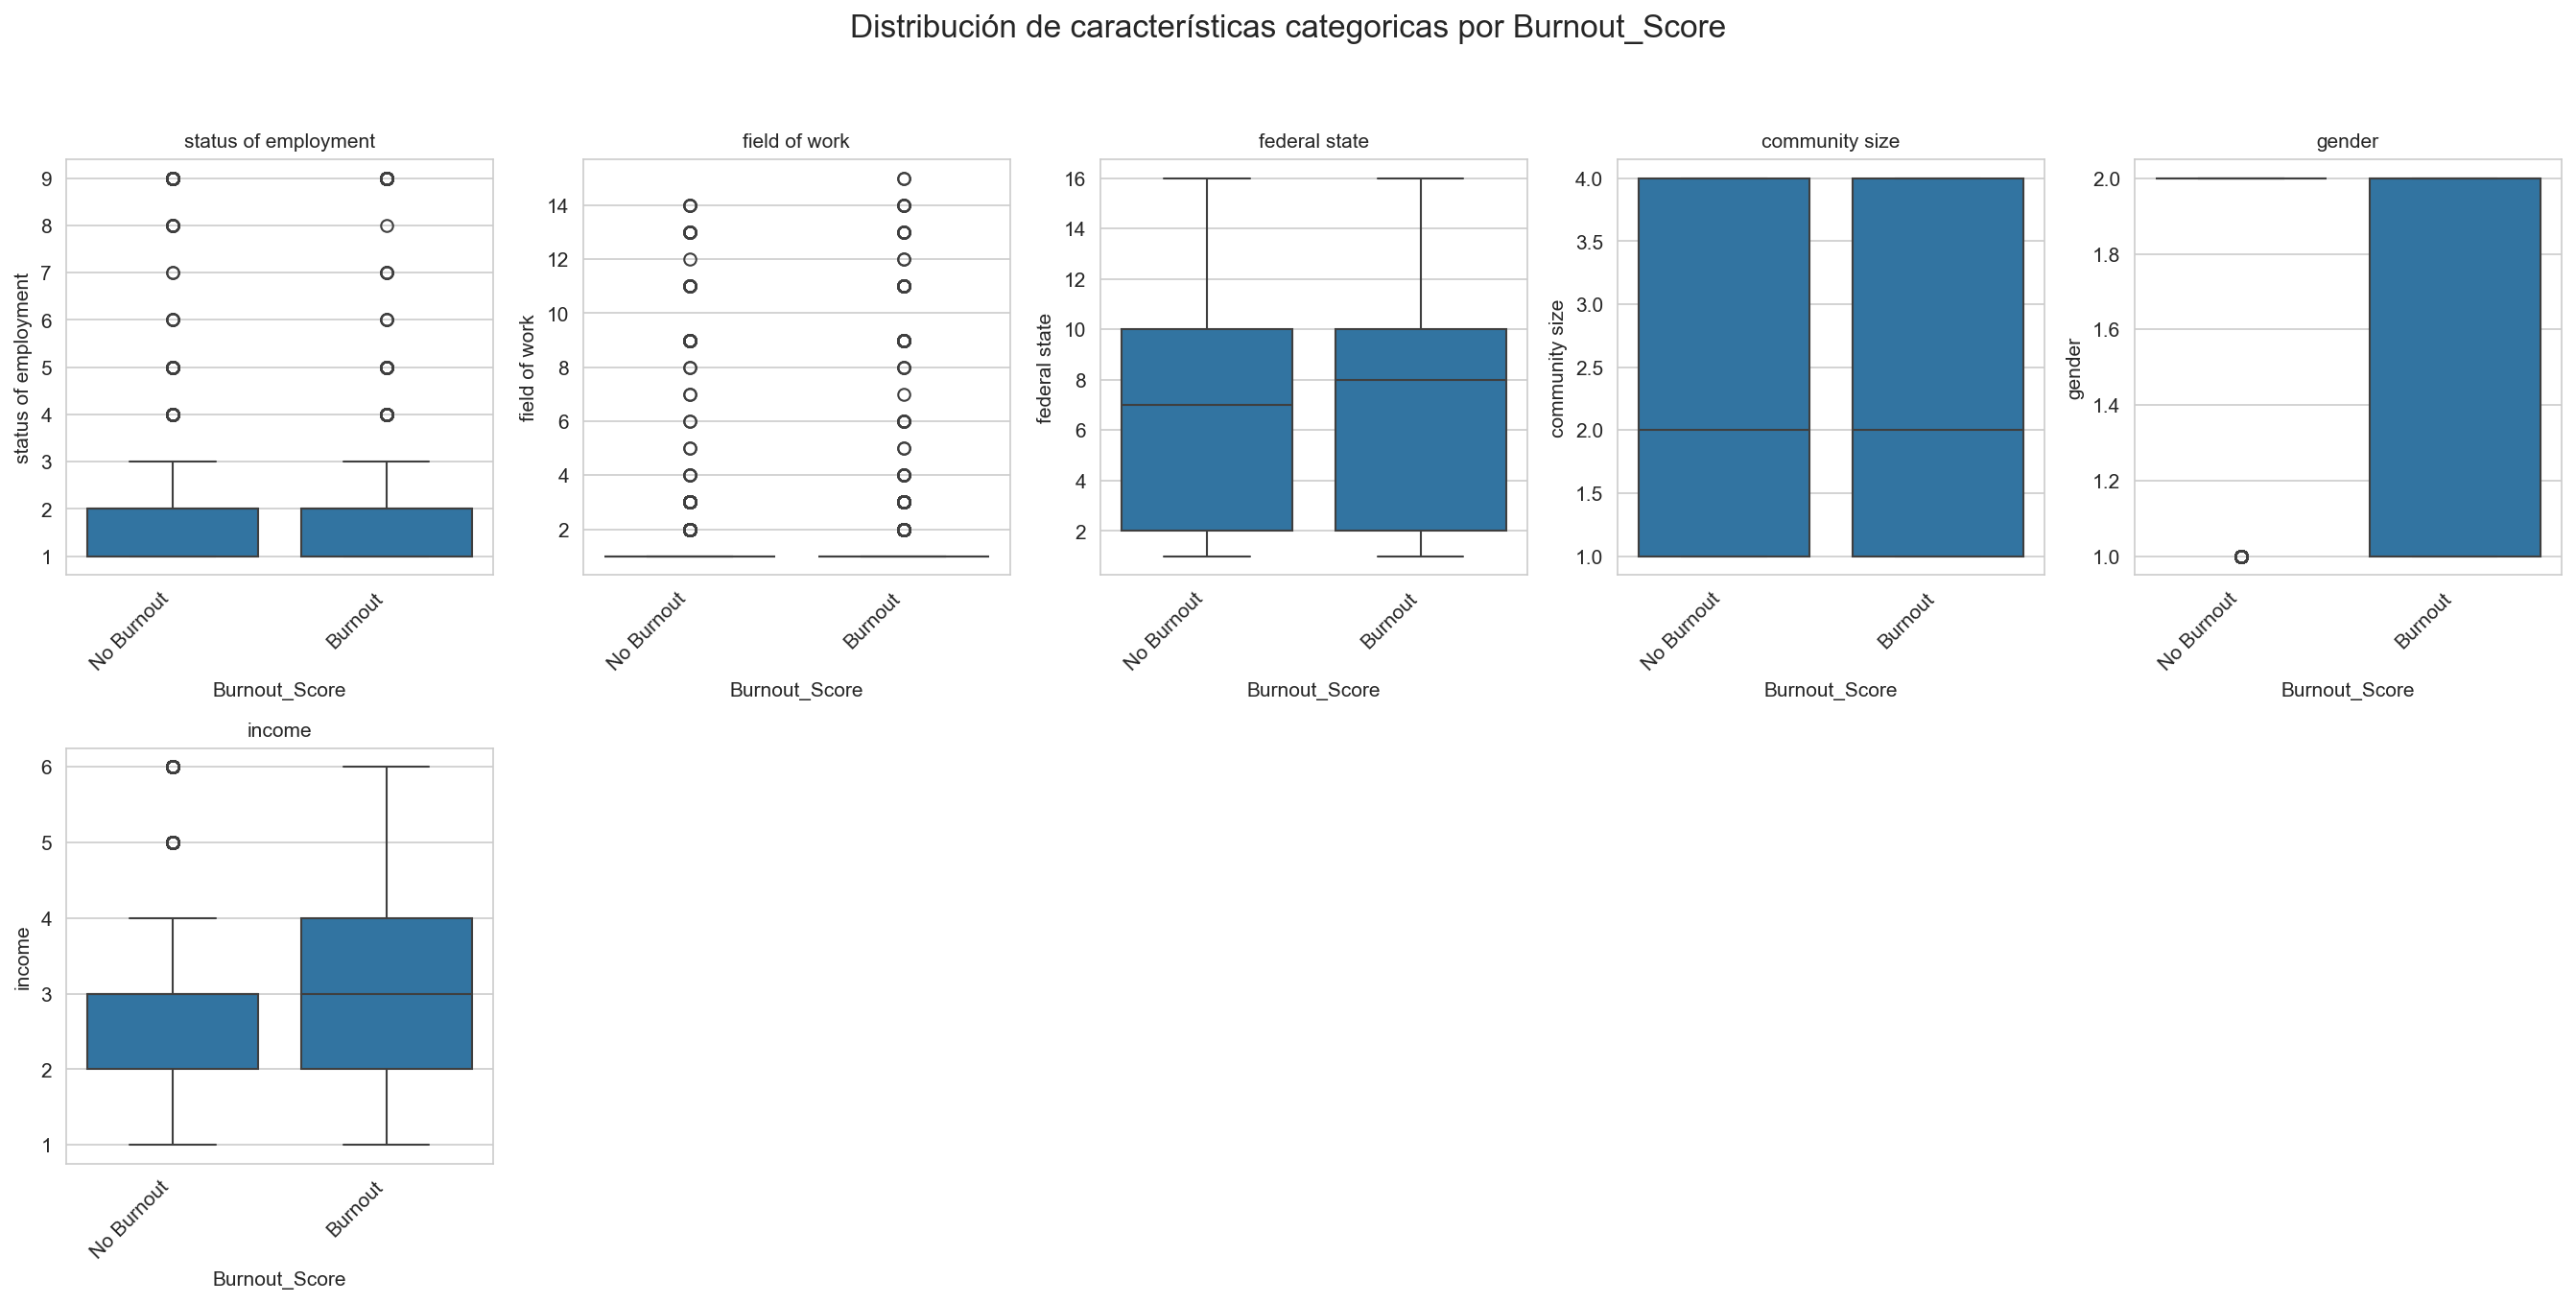

In [26]:
fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(columnas_categoricas):
    sns.boxplot(x=target, y=col, data=df_eda, ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("Burnout_Score")
    axes[i].set_ylabel(col)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["No Burnout", "Burnout"], rotation=45, ha='right')

# Hide unused axes (19 features, 20 subplots)
for j in range(len(columnas_categoricas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de características categoricas por Burnout_Score', y=1.02, fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(report_output, 'EDA_boxplots_categoricos.png'), dpi=150)
plt.show()

### Reporte de Análisis Univariante

Distribuciones de las variables ERI (Desequilibrio Esfuerzo-Recompensa): Estas características tienen rangos de 1 a 4. La mayoría de las distribuciones muestran una ligera asimetría negativa o picos en valores más altos, sugiriendo que los veterinarios tienden a reportar puntajes más bajos en factores de esfuerzo.
Las variables ERI están diseñadas para medir diferentes aspectos del esfuerzo. Un sesgo hacia puntuaciones bajas podría indicar que los encuestados perciben un nivel de esfuerzo moderado o bajo, o que hay una tendencia a subreportar altos niveles de esfuerzo.
Entender la distribución de estas variables es crucial para comprender los factores de esfuerzo. Los picos en valores bajos pueden ser informativos sobre la percepción general de la muestra.
Si hay un sesgo significativo en la respuesta, podría afectar la capacidad del modelo para capturar la verdadera relación entre el esfuerzo y el burnout.

Distribuciones de CBI: Estas características, después de la transformación a puntaje, tienen un rango de 0 a 100. Muchas de estas distribuciones muestran asimetría positiva o picos en valores más bajos.
Las variables CBI, que miden aspectos del burnout, al presentar picos en valores bajos (menos burnout) después de la transformación a puntaje, sugieren que una parte de la población no experimenta niveles elevados de burnout o que su percepción es baja.
La distribución de estas variables es fundamental para entender la manifestación del burnout en la población. La tendencia hacia valores bajos es un buen punto de partida para identificar factores protectores o de riesgo.
Una asimetría muy pronunciada podría dificultar la identificación de subgrupos con altos niveles de burnout si el modelo no está diseñado para manejar distribuciones no normales.
Edad y Horas de Trabajo: Ambas variables presentan una distribución más cercana a la normal, con una ligera asimetría.
La edad y las horas de trabajo son factores demográficos y laborales importantes que pueden influir en el burnout.
Estas distribuciones normales o ligeramente asimétricas son adecuadas para la mayoría de los modelos predictivos y permiten una interpretación más directa de su impacto.
Si hay valores atípicos extremos, podrían sesgar el análisis y el modelado si no se tratan adecuadamente.
 
Balance de la Variable Objetivo
Ligeramente desbalanceada (53.39% 'Burnout').
Indica que la población de veterinarios estudiada tiene una proporción significativa de individuos en estado de 'burnout', lo cual es relevante dado el contexto de salud ocupacional.
Es un problema común en la profesión veterinaria y este dataset lo refleja. El leve desbalance debe ser considerado en el modelado para evitar sesgos (e.g., usando métricas como F1-score o accuracy) y quizás técnicas de muestreo.
Modelos ingenuos podrían favorecer la clase mayoritaria.
Valores Faltantes e Inválidos
Mediante el uso de la biblioteca Pandas se identificó la ausencia de valores faltantes estándar dentro del archivo CSV original. No obstante, durante el proceso de validación se detectaron 14 registros donde la variable birth year presentaba el valor inválido.
Debido a que dicho valor no representa un año de nacimiento válido, estos registros fueron excluidos del análisis para preservar la consistencia y calidad del dataset.

### Reporte de Análisis Bivariante

Se generó un mapa de calor de correlación para las variables numéricas del dataset. Esta representación visual es la base para identificar la intensidad y dirección de las relaciones lineales entre pares de variables.
Los coeficientes cercanos a “1” indican correlaciones positivas fuertes, mientras que valores cercanos a “-1” representan correlaciones negativas fuertes. Por el contrario, valores próximos a cero indican relaciones lineales débiles o inexistentes.
 

Se observa una multicolinealidad esperada entre las variables CBI (entre sí) y ERI (entre sí), ya que miden constructos relacionados y componentes de los mismos índices. Esto es común en cuestionarios con múltiples ítems que evalúan una misma dimensión. Será importante considerar estas relaciones en fases de modelado para evitar la redundancia de información.
Otras relaciones entre variables numéricas son generalmente débiles, indicando que la mayoría de las características numéricas no están fuertemente correlacionadas entre sí, salvo las agrupaciones CBI y ERI.
 

Columnas CBI: Como era de esperar, dada la construcción del Burnout_Score a partir del CBI_SCORE, todas las columnas CBI muestran correlaciones muy fuertes y positivas con el Burnout_Score. Esto es fundamental, ya que el Burnout_Score se deriva directamente de la escala CBI.
Los boxplots para las variables CBI exhiben diferencias muy marcadas y consistentemente claras entre los grupos Burnout_Score negativo y Burnout_Score positivo. El grupo con Burnout_Score positivo presenta distribuciones con medianas significativamente más altas y rangos intercuartílicos desplazados hacia valores máximos en todas las variables CBI, lo que visualmente demuestra que niveles más altos en estas variables están directamente asociados con la clasificación de burnout. La superposición entre las cajas es mínima o nula, reforzando la fuerza de esta relación.
 

Columnas ERI: Las variables ERI muestran correlaciones variadas con el Burnout_Score. Atendiendo a los valores precisos del mapa de calor, las correlaciones son:
ERI_10: 0.23 (correlación positiva débil)
ERI_8: 0.32 (correlación positiva moderada-débil)
ERI_9: 0.26 (correlación positiva débil)
ERI_6: -0.29 (correlación negativa moderada-débil)
ERI_7: -0.14 (correlación negativa débil)
ERI_4: -0.10 (correlación negativa débil)
Otras ERI: Muestran correlaciones positivas o negativas muy débiles, cercanas a cero.
Los boxplots de las variables ERI ilustran estas correlaciones. Para variables con correlaciones positivas (ej., ERI_10, ERI_8, ERI_9), aunque son más débiles de lo que se había reportado inicialmente, se puede observar una ligera tendencia de los individuos con Burnout_Score positivo a tener medianas ligeramente más altas en comparación con aquellos con Burnout_Score negativo. Para las variables con correlaciones negativas (ej., ERI_6 y ERI_7), se observaría una ligera tendencia inversa, donde el grupo con Burnout_Score positivo podría mostrar medianas marginalmente más bajas.
 

Edad (age): Muestra una correlación positiva muy débil (0.07) con el Burnout_Score, apenas perceptible en el mapa de calor.
Ingresos (income): Presenta una correlación positiva débil (0.08) con el Burnout_Score, sugiriendo una tendencia marginal a que mayores ingresos se asocien con un mayor riesgo de burnout. Esto se refleja en un tono azul muy claro en el mapa de calor.
Horas de Trabajo (working_hours): La correlación con el Burnout_Score es una correlación negativa débil (-0.14), mostrando un tono azul claro en el mapa de calor.
Los boxplots para age, income y working_hours confirman una fuerte superposición entre los grupos con y sin burnout. En el caso de age, las medianas y los rangos intercuartílicos son muy similares, lo que sugiere una capacidad discriminativa limitada. Para income, el grupo con burnout presenta una mediana ligeramente superior y una mayor dispersión hacia valores altos. En working_hours, la mediana del grupo con burnout es ligeramente inferior a la observada en el grupo sin burnout, aunque las distribuciones continúan mostrando un amplio solapamiento. En conjunto, la ausencia de una separación clara entre los grupos indica que estas variables, consideradas de forma individual, tienen un poder predictivo limitado para explicar la presencia de burnout en este conjunto de datos.
 

Características Categóricas (codificadas numéricamente): Las características categóricas codificadas numéricamente presentan una superposición muy elevada entre los grupos con y sin burnout. Los boxplots de status of employment, field of work, federal state, community size, gender e income muestran medianas e intervalos intercuartílicos muy similares, con únicamente ligeras diferencias en algunas variables como income y federal state. La ausencia de una separación visual clara entre ambos grupos respalda la existencia de asociaciones muy débiles con el Burnout_Score y sugiere que estas variables, consideradas de forma individual, poseen una capacidad limitada para discriminar entre individuos con y sin burnout.
En resumen, el análisis bivariante, apoyado por la inspección de los boxplots y el mapa de calor, refuerza que las variables CBI son los factores más influyentes y distintivos en la clasificación del Burnout_Score. Las variables ERI tienen una influencia moderada a débil, con algunas variables mostrando correlaciones positivas y otras negativas, lo que sugiere una relación más compleja de lo inicialmente reportado. Factores sociodemográficos como la edad, el ingreso y las horas de trabajo, así como las demás variables categóricas, muestran relaciones lineales mucho más débiles con el burnout. Esto sugiere que para esta población de veterinarios, el burnout está predominantemente relacionado con factores psicológicos de agotamiento y, en menor medida, con la percepción de desequilibrio esfuerzo-recompensa, más que con características demográficas o laborales directas en su forma actual.

